<a href="https://colab.research.google.com/github/zeeshan3106/Machine-Learning/blob/main/Lasso%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [695]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [696]:
data = pd.read_csv("melbourne_3d_regression.csv")
data.sample(5)

,Rooms,Distance_CBD,Price
33,4,15.3,805000
72,1,26.1,75000
86,3,14.5,610000
101,3,16.4,630000
191,4,13.0,936000


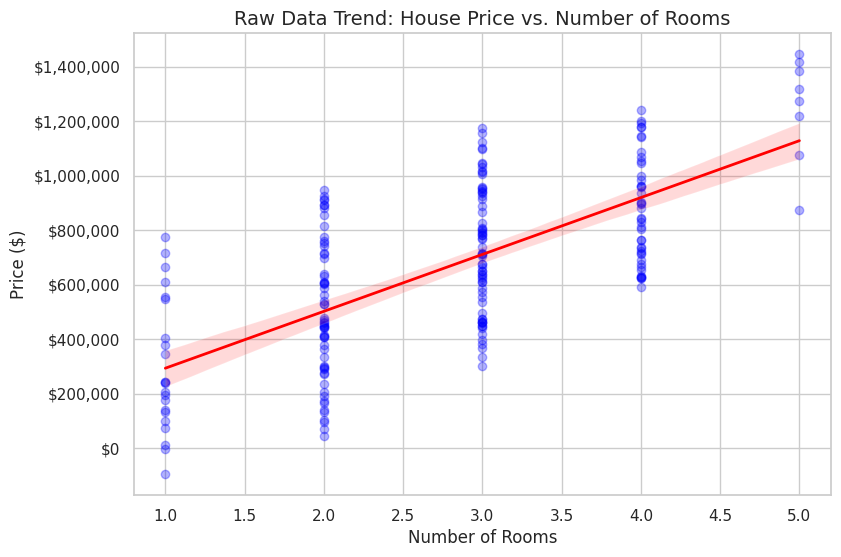

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rooms         200 non-null    int64  
 1   Distance_CBD  200 non-null    float64
 2   Price         200 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 4.8 KB


,Rooms,Distance_CBD,Price
count,200.000000,200.000000,2.000000e+02
mean,2.775000,15.625000,6.640400e+05
std,1.034274,8.497802,3.156629e+05
min,1.000000,1.100000,-9.500000e+04
25%,2.000000,8.600000,4.467500e+05
50%,3.000000,16.700000,6.660000e+05
75%,4.000000,22.525000,8.942500e+05
max,5.000000,29.700000,1.445000e+06


In [697]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))


sns.regplot(
    data=data,
    x='Rooms',
    y='Price',
    scatter_kws={'alpha':0.3, 'color': 'blue'}, # Makes raw dots semi-transparent
    line_kws={'color': 'red', 'linewidth': 2}     # Makes the trendline solid red
)

plt.title('Raw Data Trend: House Price vs. Number of Rooms', fontsize=14)
plt.xlabel('Number of Rooms', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

plt.show()


data.info()
data.describe()

In [698]:
X = data.drop("Price", axis = 1)
y = data["Price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42)



In [699]:
scaler = StandardScaler()
X_train_transform = scaler.fit_transform(X_train)
X_test_transform = scaler.transform(X_test)

lr = LinearRegression()
data = lr.fit(X_train_transform,y_train)
prediction = lr.predict(X_test_transform)
def function(Rooms,Distance_CBD):
  apple = np.array([[Rooms,Distance_CBD]])
  apple = scaler.transform(apple)

  prediction = lr.predict(apple)
  return prediction



Rooms = 1
Distance_CBD=2.5

a = function(Rooms,Distance_CBD)
a,r2_score(y_test,prediction)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


(array([644874.22605375]), 0.9069187910223131)

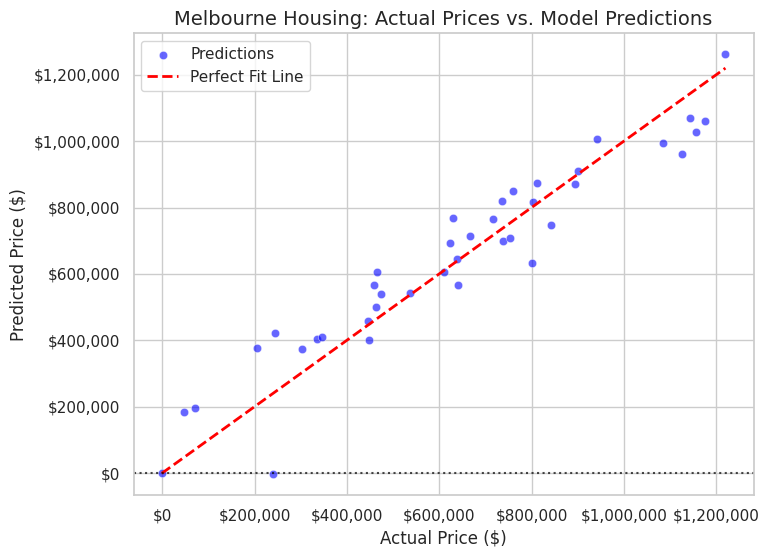

In [700]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=prediction, alpha=0.6, color='blue', label='Predictions')

perfect_line_range = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line_range, perfect_line_range, color='red', linestyle='--', linewidth=2, label='Perfect Fit Line')

plt.axhline(0, color='black', linestyle=':', alpha=0.7) # Marks the $0 price floor
plt.title('Melbourne Housing: Actual Prices vs. Model Predictions', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.legend()

plt.show()


In [701]:
scaler = StandardScaler()
X_train_transform = scaler.fit_transform(X_train)
X_test_transform = scaler.transform(X_test)
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 2)


X_train_lasso = lasso.fit(X_train_transform,y_train)
pred = lasso.predict(X_test_transform)

mean_absolute_error(y_test,pred)
r2_score(y_test,pred)




0.9069178068227738

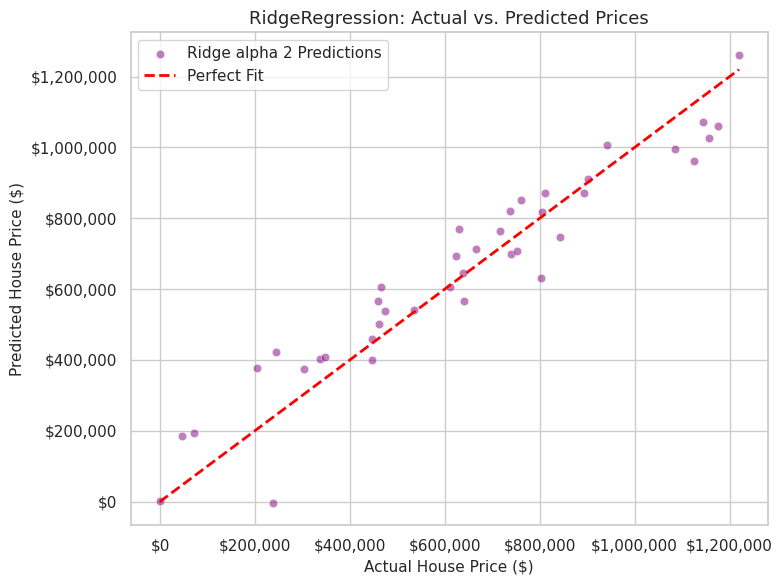

In [702]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Clear any previous plots and set up themes
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 2. Plot your actual test prices vs your polynomial test predictions
sns.scatterplot(x=y_test, y=pred, alpha=0.5, color='purple', label='Ridge alpha 2 Predictions')

# 3. Draw a baseline perfect reference line (Actual Price == Predicted Price)
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

# 4. Format labels and clean currency strings on the grid axes
plt.title('RidgeRegression: Actual vs. Predicted Prices', fontsize=13)
plt.xlabel('Actual House Price ($)', fontsize=11)
plt.ylabel('Predicted House Price ($)', fontsize=11)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.legend()

# 5. Display the graph
plt.tight_layout()
plt.show()


**Model Prediction (Polynomail):-**
***House Prices in CBD Based on Distance ***

In [703]:
# lr = LinearRegression()
# data = lr.fit(X_train_p,y_train)
# prediction = lr.predict(X_test_p)


# from sklearn.metrics import r2_score
# r2_score(y_test,prediction)
# def function(Rooms,Distance_CBD):
#   apple = np.array([[Rooms,Distance_CBD]])
#   apple = scaler.transform(apple)
#   apple = pl.transform(apple)
#   prediction = lr.predict(apple)
#   return prediction



# Rooms = 1
# Distance_CBD=2.5

# a = function(Rooms,Distance_CBD)
# pd.DataFrame(a,columns=["Price"]),r2_score(y_test,prediction)


